In [3]:
import pandas as pd
from pathlib import Path

In [4]:
data_file = Path("../data/raw/gallipoli/dati/SoilWaterContent.xlsx")

print("File found:", data_file.exists())

File found: True


In [5]:
soil_data = pd.read_excel(data_file)

print("Number of rows:", soil_data.shape[0])
print("Number of columns:", soil_data.shape[1])

Number of rows: 48531
Number of columns: 7


In [6]:
print(soil_data.columns.tolist())

['Timestamps', 'Port1', 'Port2', 'Port3', 'Port4', 'Port5', 'Port6']


In [7]:
soil_data.head(10)



,Timestamps,Port1,Port2,Port3,Port4,Port5,Port6
0,2021-06-30 19:00:00,0.293,0.221,0.262,0.236,0.269,0.238
1,2021-06-30 19:15:00,0.293,0.221,0.262,0.236,0.269,0.238
2,2021-06-30 19:30:00,0.293,0.221,0.262,0.236,0.269,0.238
3,2021-06-30 19:45:00,0.293,0.221,0.262,0.236,0.269,0.237
4,2021-06-30 20:00:00,0.293,0.221,0.262,0.236,0.269,0.237
5,2021-06-30 20:15:00,0.293,0.221,0.262,0.236,0.269,0.237
6,2021-06-30 20:30:00,0.293,0.221,0.262,0.236,0.269,0.237
7,2021-06-30 20:45:00,0.293,0.221,0.261,0.236,0.269,0.237
8,2021-06-30 21:00:00,0.293,0.221,0.261,0.236,0.268,0.237
9,2021-06-30 21:15:00,0.293,0.221,0.261,0.236,0.269,0.237


In [8]:
soil_data.head(10)

,Timestamps,Port1,Port2,Port3,Port4,Port5,Port6
0,2021-06-30 19:00:00,0.293,0.221,0.262,0.236,0.269,0.238
1,2021-06-30 19:15:00,0.293,0.221,0.262,0.236,0.269,0.238
2,2021-06-30 19:30:00,0.293,0.221,0.262,0.236,0.269,0.238
3,2021-06-30 19:45:00,0.293,0.221,0.262,0.236,0.269,0.237
4,2021-06-30 20:00:00,0.293,0.221,0.262,0.236,0.269,0.237
5,2021-06-30 20:15:00,0.293,0.221,0.262,0.236,0.269,0.237
6,2021-06-30 20:30:00,0.293,0.221,0.262,0.236,0.269,0.237
7,2021-06-30 20:45:00,0.293,0.221,0.261,0.236,0.269,0.237
8,2021-06-30 21:00:00,0.293,0.221,0.261,0.236,0.268,0.237
9,2021-06-30 21:15:00,0.293,0.221,0.261,0.236,0.269,0.237


In [9]:
soil_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48531 entries, 0 to 48530
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Timestamps  48531 non-null  datetime64[us]
 1   Port1       48531 non-null  float64       
 2   Port2       48531 non-null  float64       
 3   Port3       48531 non-null  float64       
 4   Port4       48531 non-null  float64       
 5   Port5       48531 non-null  float64       
 6   Port6       48531 non-null  float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 2.6 MB


In [10]:
print("Start:", soil_data["Timestamps"].min())
print("End:", soil_data["Timestamps"].max())

Start: 2021-06-30 19:00:00
End: 2023-02-28 23:45:00


In [11]:
time_gaps = soil_data["Timestamps"].diff()

time_gaps.value_counts().head(10)

Timestamps
0 days 00:15:00    48331
0 days 00:45:00       14
0 days 01:00:00       12
1 days 00:00:00       12
0 days 01:15:00       10
0 days 00:30:00        9
0 days 03:45:00        6
0 days 23:45:00        6
0 days 04:00:00        4
0 days 01:45:00        4
Name: count, dtype: int64

In [12]:
expected_interval = pd.Timedelta(minutes=15)

irregular_gaps = time_gaps[
    (time_gaps.notna()) & (time_gaps != expected_interval)
]

print("Total intervals:", len(time_gaps) - 1)
print("Regular 15-minute intervals:", (time_gaps == expected_interval).sum())
print("Irregular intervals:", len(irregular_gaps))

Total intervals: 48530
Regular 15-minute intervals: 48331
Irregular intervals: 199


In [13]:
soil_data[["Port1", "Port2", "Port3", "Port4", "Port5", "Port6"]].describe()

,Port1,Port2,Port3,Port4,Port5,Port6
count,48531.000000,48531.000000,48531.000000,48531.000000,48531.000000,48531.000000
mean,0.259017,0.192442,0.199995,0.203841,0.231120,0.205213
std,0.043952,0.038868,0.038325,0.020871,0.039295,0.035232
min,0.142000,0.119000,0.144000,0.154000,0.165000,0.140000
25%,0.234000,0.166000,0.165000,0.190000,0.191000,0.175000
50%,0.273000,0.194000,0.200000,0.203000,0.236000,0.203000
75%,0.293000,0.226000,0.226000,0.219000,0.265000,0.235000
max,0.339000,0.286000,0.320000,0.321000,0.366000,0.350000


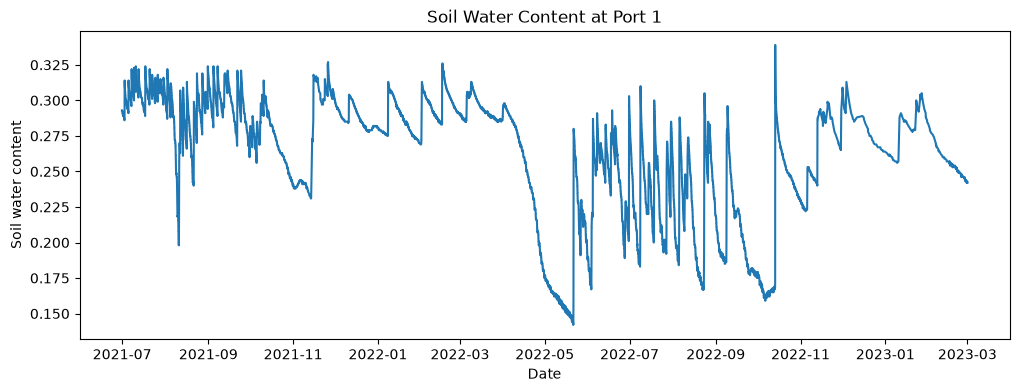

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(soil_data["Timestamps"], soil_data["Port1"])

plt.xlabel("Date")
plt.ylabel("Soil water content")
plt.title("Soil Water Content at Port 1")

plt.show()

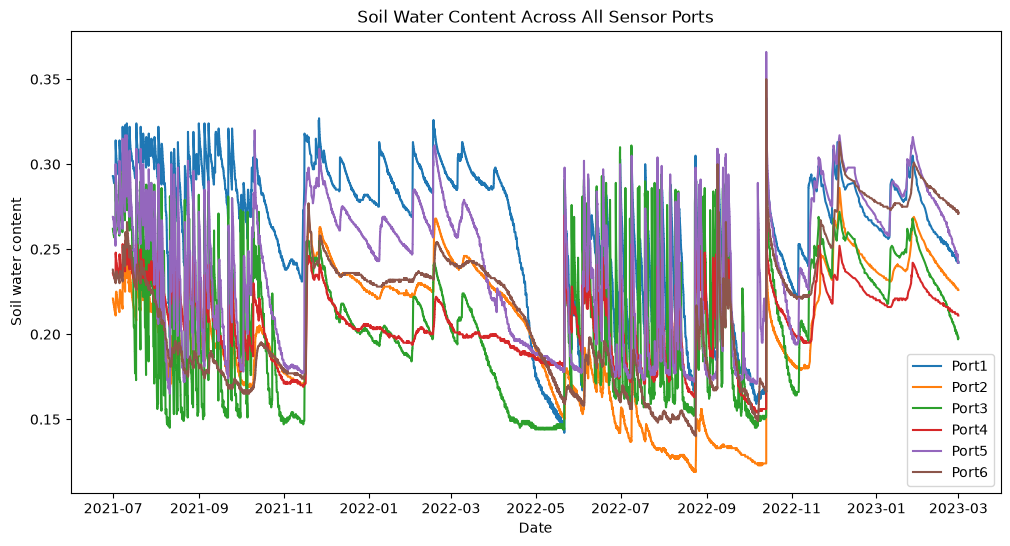

In [15]:
sensor_columns = ["Port1", "Port2", "Port3", "Port4", "Port5", "Port6"]

plt.figure(figsize=(12, 6))

for sensor in sensor_columns:
    plt.plot(
        soil_data["Timestamps"],
        soil_data[sensor],
        label=sensor
    )

plt.xlabel("Date")
plt.ylabel("Soil water content")
plt.title("Soil Water Content Across All Sensor Ports")
plt.legend()
plt.show()

In [16]:
irrigation_file = Path(
    "../data/raw/gallipoli/dati/TREND_Portata_Uliveto_date_convertito.xlsx"
)

irrigation_excel = pd.ExcelFile(irrigation_file)

print("File found:", irrigation_file.exists())
print("Sheets:", irrigation_excel.sheet_names)

File found: True
Sheets: ['Sheet1']


In [17]:
irrigation_data = pd.read_excel(irrigation_file)

print("Number of rows:", irrigation_data.shape[0])
print("Number of columns:", irrigation_data.shape[1])
print("Columns:", irrigation_data.columns.tolist())

Number of rows: 32263
Number of columns: 2
Columns: ['Uliv.PORTATA (l/s)', 'Data']


In [18]:
irrigation_data.head(10)

,Uliv.PORTATA (l/s),Data
0,0.0,2022-04-07 10:30:00
1,0.0,2022-04-07 10:45:00
2,0.0,2022-04-07 11:00:00
3,0.0,2022-04-07 11:15:00
4,0.0,2022-04-07 11:30:00
5,0.0,2022-04-07 11:45:00
6,0.0,2022-04-07 12:00:00
7,0.0,2022-04-07 12:15:00
8,0.0,2022-04-07 12:30:00
9,0.0,2022-04-07 12:45:00


In [19]:
irrigation_on = irrigation_data[
    irrigation_data["Uliv.PORTATA (l/s)"] > 0
]

irrigation_on.head(10)

,Uliv.PORTATA (l/s),Data
1226,1.99,2022-05-21 11:45:00
1227,2.07,2022-05-21 12:00:00
1228,2.16,2022-05-21 12:15:00
1229,2.12,2022-05-21 12:30:00
1230,2.14,2022-05-21 12:45:00
1231,2.18,2022-05-21 13:00:00
1232,2.19,2022-05-21 13:15:00
1233,2.29,2022-05-21 13:30:00
1234,2.19,2022-05-21 13:45:00
1235,2.27,2022-05-21 14:00:00


In [20]:
irrigation_data["Uliv.PORTATA (l/s)"] > 0



0        False
1        False
2        False
3        False
4        False
         ...  
32258    False
32259    False
32260    False
32261    False
32262    False
Name: Uliv.PORTATA (l/s), Length: 32263, dtype: bool

In [21]:
irrigation_on = irrigation_data[
    irrigation_data["Uliv.PORTATA (l/s)"] > 0
]

irrigation_on.head(10)


,Uliv.PORTATA (l/s),Data
1226,1.99,2022-05-21 11:45:00
1227,2.07,2022-05-21 12:00:00
1228,2.16,2022-05-21 12:15:00
1229,2.12,2022-05-21 12:30:00
1230,2.14,2022-05-21 12:45:00
1231,2.18,2022-05-21 13:00:00
1232,2.19,2022-05-21 13:15:00
1233,2.29,2022-05-21 13:30:00
1234,2.19,2022-05-21 13:45:00
1235,2.27,2022-05-21 14:00:00


In [22]:
print("Irrigation start:", irrigation_data["Data"].min())
print("Irrigation end:", irrigation_data["Data"].max())

print("Soil moisture start:", soil_data["Timestamps"].min())
print("Soil moisture end:", soil_data["Timestamps"].max())


Irrigation start: 2022-04-07 10:30:00
Irrigation end: 2023-08-21 00:00:00
Soil moisture start: 2021-06-30 19:00:00
Soil moisture end: 2023-02-28 23:45:00


In [23]:
weather_file = Path(
    "../data/raw/gallipoli/dati/porta1_meteo_piogge.xlsx"
)

weather_excel = pd.ExcelFile(weather_file)

print("File found:", weather_file.exists())
print("Sheets:", weather_excel.sheet_names)

File found: True
Sheets: ['pioggia', 'meteo', 'porta1']


In [24]:
for sheet in weather_excel.sheet_names:
    df = pd.read_excel(weather_file, sheet_name=sheet)
    print(f"\nSheet: {sheet}")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Column names:", df.columns.tolist())


Sheet: pioggia
Rows: 58819
Columns: 2
Column names: ['Data', 'Gallipoli | Pioggia accumulo 5min[p_sum_5min]']

Sheet: meteo
Rows: 78957
Columns: 2
Column names: ['Data', 'Gallipoli | Temperatura media 15 minuti[ta_avg_15min]']

Sheet: porta1
Rows: 48531
Columns: 4
Column names: ['Timestamps', 'Port1:WaterContent', 'Port1:SoilTemperature', 'Port1:Saturation']


In [25]:
porta1_data = pd.read_excel(weather_file, sheet_name="porta1")

for column in porta1_data.columns:
    print(column)

Timestamps
Port1:WaterContent
Port1:SoilTemperature
Port1:Saturation


In [26]:
porta1_data.head(10)

,Timestamps,Port1:WaterContent,Port1:SoilTemperature,Port1:Saturation
0,2021-06-30 19:00:00,0.293,30.0,0.87
1,2021-06-30 19:15:00,0.293,30.0,0.87
2,2021-06-30 19:30:00,0.293,30.0,0.87
3,2021-06-30 19:45:00,0.293,30.0,0.87
4,2021-06-30 20:00:00,0.293,30.0,0.87
5,2021-06-30 20:15:00,0.293,30.1,0.87
6,2021-06-30 20:30:00,0.293,30.1,0.87
7,2021-06-30 20:45:00,0.293,30.1,0.87
8,2021-06-30 21:00:00,0.293,30.1,0.87
9,2021-06-30 21:15:00,0.293,30.1,0.87


In [27]:
porta1_data[
    ["Port1:WaterContent", "Port1:SoilTemperature", "Port1:Saturation"]
].describe()

,Port1:WaterContent,Port1:SoilTemperature,Port1:Saturation
count,48531.000000,48531.000000,48531.000000
mean,0.259017,20.344635,0.478309
std,0.043952,7.660309,0.360640
min,0.142000,6.600000,0.000000
25%,0.234000,12.700000,0.220000
50%,0.273000,20.600000,0.450000
75%,0.293000,27.800000,0.720000
max,0.339000,32.700000,3.530000


In [28]:
rainfall_data = pd.read_excel(
    weather_file,
    sheet_name="pioggia"
)

rainfall_data.head(10)

,Data,Gallipoli | Pioggia accumulo 5min[p_sum_5min]
0,2021-06-30 00:15:00,0.0
1,2021-06-30 00:30:00,0.0
2,2021-06-30 00:45:00,0.0
3,2021-06-30 01:00:00,0.0
4,2021-06-30 01:15:00,0.0
5,2021-06-30 01:30:00,0.0
6,2021-06-30 01:45:00,0.0
7,2021-06-30 02:00:00,0.0
8,2021-06-30 02:15:00,0.0
9,2021-06-30 02:30:00,0.0


In [29]:
rain_column = "Gallipoli | Pioggia accumulo 5min[p_sum_5min]"

rain_events = rainfall_data[
    rainfall_data[rain_column] > 0
]

rain_events.head(10)

,Data,Gallipoli | Pioggia accumulo 5min[p_sum_5min]
1767,2021-07-18 10:00:00,0.8
5513,2021-08-26 10:30:00,0.4
5514,2021-08-26 10:45:00,0.2
5545,2021-08-26 18:30:00,6.2
5546,2021-08-26 18:45:00,1.8
5823,2021-08-29 16:00:00,0.2
5824,2021-08-29 16:15:00,0.2
5825,2021-08-29 16:30:00,1.8
5826,2021-08-29 16:45:00,0.4
5827,2021-08-29 17:00:00,1.4


In [30]:
rain_time_gaps = rainfall_data["Data"].diff()

rain_time_gaps.value_counts().head(10)

Data
0 days 00:15:00    58817
0 days 00:30:00        1
Name: count, dtype: int64

In [31]:
print("Rainfall start:", rainfall_data["Data"].min())
print("Rainfall end:", rainfall_data["Data"].max())

Rainfall start: 2021-06-30 00:15:00
Rainfall end: 2023-03-04 17:00:00


In [32]:
temperature_data = pd.read_excel(
    weather_file,
    sheet_name="meteo"
)

temperature_data.head(10)

,Data,Gallipoli | Temperatura media 15 minuti[ta_avg_15min]
0,2022-08-01 00:15:00,27.0
1,2022-08-01 00:30:00,26.9
2,2022-08-01 00:45:00,26.8
3,2022-08-01 01:00:00,26.8
4,2022-08-01 01:15:00,26.8
5,2022-08-01 01:30:00,26.7
6,2022-08-01 01:45:00,26.6
7,2022-08-01 02:00:00,26.5
8,2022-08-01 02:15:00,26.4
9,2022-08-01 02:30:00,26.3


In [33]:
print("Temperature start:", temperature_data["Data"].min())
print("Temperature end:", temperature_data["Data"].max())

Temperature start: 2022-08-01 00:15:00
Temperature end: 2024-10-31 11:15:00


In [34]:
temperature_gaps = temperature_data["Data"].diff()

temperature_gaps.value_counts().head(10)

Data
0 days 00:15:00    78956
Name: count, dtype: int64

In [35]:
start_date = "2022-08-01 00:15:00"
end_date = "2023-02-28 23:45:00"

soil_common = soil_data[
    (soil_data["Timestamps"] >= start_date) &
    (soil_data["Timestamps"] <= end_date)
].copy()

print("Rows:", len(soil_common))
print("Start:", soil_common["Timestamps"].min())
print("End:", soil_common["Timestamps"].max())

Rows: 11770
Start: 2022-08-01 00:15:00
End: 2023-02-28 23:45:00


In [36]:
rainfall_common = rainfall_data[
    (rainfall_data["Data"] >= start_date) &
    (rainfall_data["Data"] <= end_date)
].copy()

rainfall_common = rainfall_common.rename(
    columns={
        "Data": "Timestamps",
        rain_column: "Rainfall"
    }
)

print("Rows:", len(rainfall_common))
print("Start:", rainfall_common["Timestamps"].min())
print("End:", rainfall_common["Timestamps"].max())

rainfall_common.head()

Rows: 20351
Start: 2022-08-01 00:15:00
End: 2023-02-28 23:45:00


,Timestamps,Rainfall
38111,2022-08-01 00:15:00,0.0
38112,2022-08-01 00:30:00,0.0
38113,2022-08-01 00:45:00,0.0
38114,2022-08-01 01:00:00,0.0
38115,2022-08-01 01:15:00,0.0


In [37]:
duplicate_rain_times = rainfall_common["Timestamps"].duplicated().sum()

print("Duplicate rainfall timestamps:", duplicate_rain_times)
print("Unique rainfall timestamps:", rainfall_common["Timestamps"].nunique())
print("Total rainfall rows:", len(rainfall_common))

Duplicate rainfall timestamps: 0
Unique rainfall timestamps: 20351
Total rainfall rows: 20351


In [38]:
soil_common_gaps = soil_common["Timestamps"].diff()

soil_common_gaps.value_counts().head(15)

Timestamps
0 days 00:15:00    11626
1 days 00:00:00       12
0 days 00:45:00        8
0 days 01:00:00        7
0 days 23:45:00        6
0 days 01:15:00        5
0 days 00:30:00        5
0 days 14:00:00        4
0 days 13:30:00        3
0 days 22:45:00        3
0 days 23:30:00        3
0 days 21:00:00        3
0 days 04:15:00        3
0 days 12:00:00        3
0 days 04:00:00        3
Name: count, dtype: int64

In [39]:
largest_soil_gaps = soil_common[
    soil_common_gaps > pd.Timedelta("1 day")
][["Timestamps"]].copy()

largest_soil_gaps["Gap"] = soil_common_gaps[
    soil_common_gaps > pd.Timedelta("1 day")
]

largest_soil_gaps.sort_values("Gap", ascending=False).head(10)

,Timestamps,Gap
46868,2022-12-15 12:30:00,4 days 00:00:00
46867,2022-12-11 12:30:00,2 days 00:00:00
47035,2023-01-19 11:15:00,1 days 19:45:00
46819,2022-11-28 00:15:00,1 days 18:00:00
46852,2022-12-05 11:45:00,1 days 11:30:00
47055,2023-01-22 00:15:00,1 days 10:45:00
46958,2023-01-03 11:15:00,1 days 10:30:00
46967,2023-01-05 11:30:00,1 days 10:30:00
46800,2022-11-20 10:30:00,1 days 10:15:00
46955,2023-01-02 00:15:00,1 days 09:15:00


In [40]:
soil_monthly_counts = (
    soil_common
    .set_index("Timestamps")
    .resample("ME")
    .size()
)

soil_monthly_counts

Timestamps
2022-08-31    2975
2022-09-30    2880
2022-10-31    2980
2022-11-30    1248
2022-12-31     111
2023-01-31     176
2023-02-28    1400
Freq: ME, dtype: int64

In [41]:
model_data = pd.merge(
    soil_common,
    rainfall_common,
    on="Timestamps",
    how="left"
)

print("Soil rows before merge:", len(soil_common))
print("Rows after merge:", len(model_data))
print("Missing rainfall values:", model_data["Rainfall"].isna().sum())

model_data.head()

Soil rows before merge: 11770
Rows after merge: 11770
Missing rainfall values: 0


,Timestamps,Port1,Port2,Port3,Port4,Port5,Port6,Rainfall
0,2022-08-01 00:15:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0
1,2022-08-01 00:30:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0
2,2022-08-01 00:45:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0
3,2022-08-01 01:00:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0
4,2022-08-01 01:15:00,0.257,0.133,0.172,0.204,0.2,0.155,0.0


In [42]:
irrigation_common = irrigation_data[
    (irrigation_data["Data"] >= start_date) &
    (irrigation_data["Data"] <= end_date)
].copy()

irrigation_common = irrigation_common.rename(
    columns={
        "Data": "Timestamps",
        "Uliv.PORTATA (l/s)": "Irrigation"
    }
)

print("Rows:", len(irrigation_common))
print("Start:", irrigation_common["Timestamps"].min())
print("End:", irrigation_common["Timestamps"].max())
print("Duplicate timestamps:", irrigation_common["Timestamps"].duplicated().sum())

irrigation_common.head()

Rows: 15555
Start: 2022-08-01 00:15:00
End: 2023-02-28 23:45:00
Duplicate timestamps: 0


,Irrigation,Timestamps
8092,0.0,2022-08-01 00:15:00
8093,0.0,2022-08-01 00:30:00
8094,0.0,2022-08-01 00:45:00
8095,0.0,2022-08-01 01:00:00
8096,0.0,2022-08-01 01:15:00


In [43]:
model_data = pd.merge(
    model_data,
    irrigation_common[["Timestamps", "Irrigation"]],
    on="Timestamps",
    how="left"
)

print("Rows after irrigation merge:", len(model_data))
print("Missing irrigation values:", model_data["Irrigation"].isna().sum())

model_data.head()

Rows after irrigation merge: 11770
Missing irrigation values: 652


,Timestamps,Port1,Port2,Port3,Port4,Port5,Port6,Rainfall,Irrigation
0,2022-08-01 00:15:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0
1,2022-08-01 00:30:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0
2,2022-08-01 00:45:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0
3,2022-08-01 01:00:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0
4,2022-08-01 01:15:00,0.257,0.133,0.172,0.204,0.2,0.155,0.0,0.0


In [44]:
temperature_common = temperature_data[
    (temperature_data["Data"] >= start_date) &
    (temperature_data["Data"] <= end_date)
].copy()

temperature_common = temperature_common.rename(
    columns={
        "Data": "Timestamps",
        "Gallipoli | Temperatura media 15 minuti[ta_avg_15min]": "Temperature"
    }
)

model_data = pd.merge(
    model_data,
    temperature_common[["Timestamps", "Temperature"]],
    on="Timestamps",
    how="left"
)

print("Final rows:", len(model_data))
print("Missing temperature:", model_data["Temperature"].isna().sum())
print("\nMissing values:")
print(model_data.isna().sum())

model_data.head()

Final rows: 11770
Missing temperature: 0

Missing values:
Timestamps       0
Port1            0
Port2            0
Port3            0
Port4            0
Port5            0
Port6            0
Rainfall         0
Irrigation     652
Temperature      0
dtype: int64


,Timestamps,Port1,Port2,Port3,Port4,Port5,Port6,Rainfall,Irrigation,Temperature
0,2022-08-01 00:15:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,27.0
1,2022-08-01 00:30:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.9
2,2022-08-01 00:45:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.8
3,2022-08-01 01:00:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.8
4,2022-08-01 01:15:00,0.257,0.133,0.172,0.204,0.2,0.155,0.0,0.0,26.8


In [45]:
missing_irrigation = model_data[
    model_data["Irrigation"].isna()
]

print("Missing irrigation rows:", len(missing_irrigation))
print("First missing timestamp:", missing_irrigation["Timestamps"].min())
print("Last missing timestamp:", missing_irrigation["Timestamps"].max())

missing_irrigation[["Timestamps"]].head(10)

Missing irrigation rows: 652
First missing timestamp: 2022-11-28 00:15:00
Last missing timestamp: 2023-02-15 04:15:00


,Timestamps
10058,2022-11-28 00:15:00
10059,2022-11-28 04:45:00
10076,2022-11-30 00:15:00
10077,2022-11-30 00:30:00
10078,2022-11-30 04:45:00
10079,2022-11-30 07:15:00
10080,2022-11-30 10:30:00
10081,2022-11-30 10:45:00
10082,2022-11-30 11:15:00
10083,2022-12-01 00:15:00


In [46]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

output_file = processed_dir / "irrigation_model_data.csv"

model_data.to_csv(output_file, index=False)

print("Saved:", output_file)
print("Rows:", len(model_data))
print("Columns:", len(model_data.columns))

Saved: ../data/processed/irrigation_model_data.csv
Rows: 11770
Columns: 10


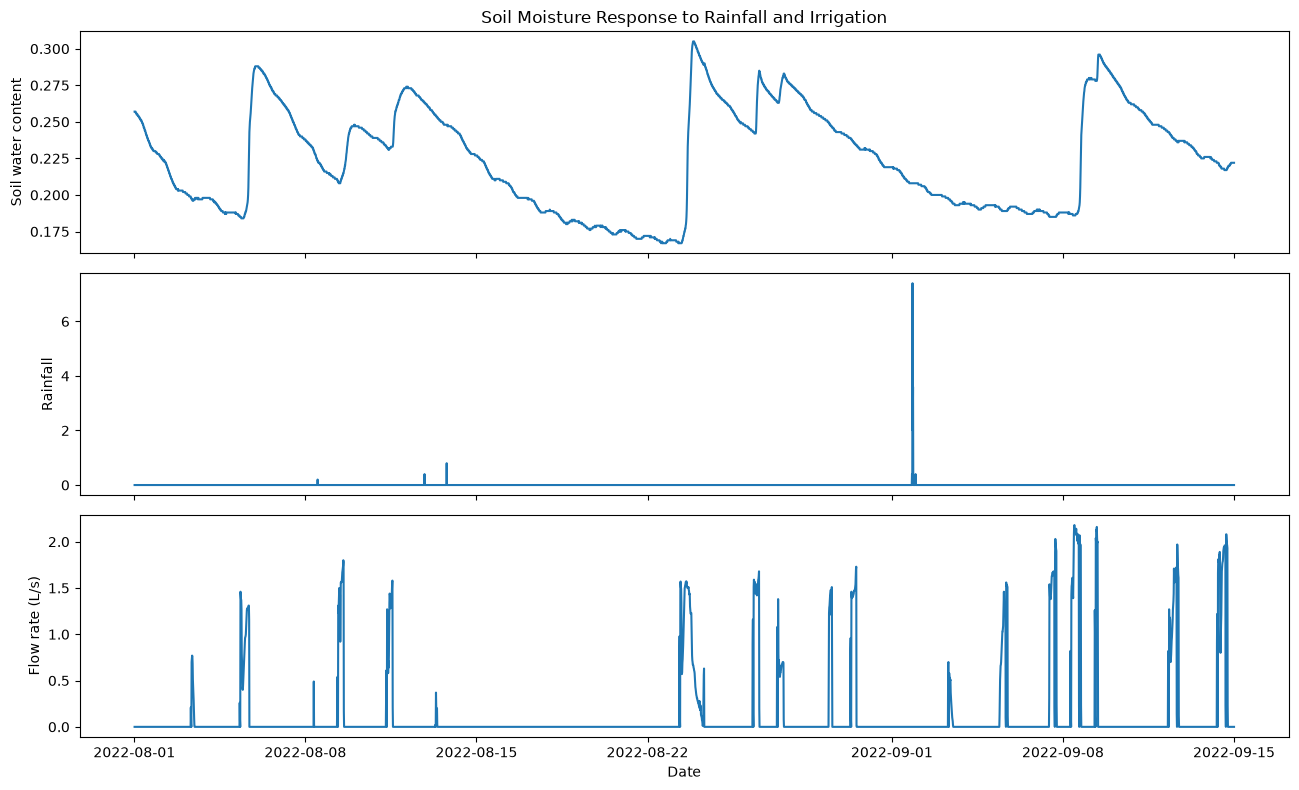

In [47]:
plot_data = model_data[
    (model_data["Timestamps"] >= "2022-08-01") &
    (model_data["Timestamps"] <= "2022-09-15")
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(13, 8),
    sharex=True
)

axes[0].plot(
    plot_data["Timestamps"],
    plot_data["Port1"]
)
axes[0].set_ylabel("Soil water content")
axes[0].set_title("Soil Moisture Response to Rainfall and Irrigation")

axes[1].plot(
    plot_data["Timestamps"],
    plot_data["Rainfall"]
)
axes[1].set_ylabel("Rainfall")

axes[2].plot(
    plot_data["Timestamps"],
    plot_data["Irrigation"]
)
axes[2].set_ylabel("Flow rate (L/s)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

## Initial observations

The soil-moisture measurements are mostly recorded at 15-minute intervals, although some gaps appear in the later part of the dataset. The six sensor ports follow similar general patterns but show noticeable differences in their moisture levels and responses over time.

For the first integrated dataset, I used the period from August 2022 to February 2023 because soil moisture, rainfall, irrigation flow and air temperature are all available during this period.

The plot above shows repeated periods of gradual soil-moisture decline followed by relatively rapid increases. Some of these increases occur around irrigation or rainfall events. This suggests that a water-balance model may be able to capture part of the observed soil-moisture behaviour.

The irrigation record also contains missing measurements during part of the study period. I have kept these values as missing rather than assuming that missing measurements represent zero irrigation.

These observations will guide the development of the soil-water model in the next stage.